# 04b_feature_space_difficult_cases_mel_nv

Focused feature-space analysis for the clean MEL vs NV PanDerm models.

This notebook does three things:

1. **Fixes the metric leakage problem**  
   kNN and linear probe are trained on train + val features and evaluated on the test set.

2. **Exports difficult cases**  
   false negative MEL, false positive NV, low-confidence cases, and nearest-neighbor tables.

3. **Creates last-block-only t-SNE and UMAP plots**  
   The plots focus on correctness categories:
   - **TP MEL**: true MEL, predicted MEL
   - **FN MEL**: true MEL, predicted NV
   - **TN NV**: true NV, predicted NV
   - **FP MEL**: true NV, predicted MEL

Important terminology:
For binary MEL vs NV, this notebook treats **MEL as the positive class** because it is clinically critical.  
So `FP MEL` means an NV image that the model predicts as MEL.  
`FN MEL` means a MEL image that the model misses and predicts as NV.


## 0. Configuration

In [1]:

from pathlib import Path
import sys
import os
import random
import warnings
from collections import OrderedDict

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, silhouette_score
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")

# =============================================================================
# Path setup
# =============================================================================
# Local notebook path:
#   notebooks/mel_nv/04b_feature_space_difficult_cases_mel_nv.ipynb
#
# On local Mac, this should resolve via ../...
# On UBELIX, if needed, set REPO_ROOT manually below.
CANDIDATES = [
    Path("../..").resolve(),
    Path("..").resolve() / "master-thesis",
    Path.cwd(),
    Path.home() / "projects" / "master-thesis",
]
REPO_ROOT = None
for c in CANDIDATES:
    if (c / "data" / "HAM10000").exists() and (c / "external" / "PanDerm" / "classification").exists():
        REPO_ROOT = c
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve REPO_ROOT. Set it manually in this cell.")

PANDERM_CLASSIFICATION_DIR = REPO_ROOT / "external" / "PanDerm" / "classification"
if str(PANDERM_CLASSIFICATION_DIR) not in sys.path:
    sys.path.insert(0, str(PANDERM_CLASSIFICATION_DIR))

CSV_PATH = REPO_ROOT / "data" / "HAM10000" / "mel_nv" / "ham_mel_nv_clean.csv"
ROOT_PATH = REPO_ROOT / "data" / "HAM10000"

OUT_ROOT = REPO_ROOT / "outputs" / "mel_nv" / "feature_space_difficult_cases_last_block"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# =============================================================================
# Data/model settings
# =============================================================================
NB_CLASSES = 2
CLASS_NAMES = ["MEL", "NV"]
MEL_INDEX = 0
NV_INDEX = 1

LABEL_COL = "binary_label"
GT_COL = "gt_label"
IMAGE_COL = "image_rel_path"
ID_COL = "image_id"

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0  # safest in notebooks; avoids multiprocessing pickling crashes
SEED = 0

# Last block only.
SELECTED_BLOCK = -1

# Runtime control. Use None for final run.
MAX_TRAIN_SAMPLES = None
MAX_TEST_SAMPLES = None

# Feature modes:
# - matching_pooling: CLS model uses CLS token, GAP model uses mean patch pooling
# - cls_token: always CLS token
# - gap_patch_tokens: always mean over patch tokens
FEATURE_MODE = "matching_pooling"

# Dimensionality reduction
RUN_TSNE = True
RUN_UMAP = True
TSNE_PERPLEXITY = 30
TSNE_RANDOM_STATE = SEED

# kNN / linear probe
KNN_K = 5

# Low-confidence cases
LOW_CONF_MARGIN = 0.15

SCENARIOS = [
    {
        "name": "CLS HA 0.5",
        "short_name": "cls_ha05",
        "checkpoint": REPO_ROOT / "external" / "checkpoints4" / "checkpoint-best-cls.pth",
        "use_mean_pooling": False,
        "pooling_name": "CLS token pooling",
    },
    {
        "name": "GAP HA 0.25",
        "short_name": "gap_ha025",
        "checkpoint": REPO_ROOT / "external" / "checkpoints4" / "checkpoint-best-gap.pth",
        "use_mean_pooling": True,
        "pooling_name": "GAP / mean pooling",
    },
]

print("REPO_ROOT:", REPO_ROOT)
print("CSV exists:", CSV_PATH.exists(), CSV_PATH)
print("ROOT exists:", ROOT_PATH.exists(), ROOT_PATH)
print("OUT_ROOT:", OUT_ROOT)
print("Selected block:", SELECTED_BLOCK)
print("Feature mode:", FEATURE_MODE)
for s in SCENARIOS:
    print("\n", s["name"])
    print("  checkpoint exists:", Path(s["checkpoint"]).exists(), s["checkpoint"])
    print("  use_mean_pooling:", s["use_mean_pooling"])


REPO_ROOT: /Users/choekyelnyungmartsang/Developer/master-thesis
CSV exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/mel_nv/ham_mel_nv_clean.csv
ROOT exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000
OUT_ROOT: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block
Selected block: -1
Feature mode: matching_pooling

 CLS HA 0.5
  checkpoint exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/external/checkpoints4/checkpoint-best-cls.pth
  use_mean_pooling: False

 GAP HA 0.25
  checkpoint exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/external/checkpoints4/checkpoint-best-gap.pth
  use_mean_pooling: True


## 1. Reproducibility and device

In [2]:

def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)


DEVICE: mps


## 2. Dataset and dataloaders

In [3]:

class CSVDermDataset(Dataset):
    def __init__(self, df, root_path, transform=None, image_col="image_rel_path", label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.root_path = Path(root_path)
        self.transform = transform
        self.image_col = image_col
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def resolve_path(self, value):
        p = Path(str(value))
        if p.is_absolute():
            return p
        return (self.root_path / p).resolve()

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.resolve_path(row[self.image_col])
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = int(row[self.label_col])
        image_id = str(row[ID_COL]) if ID_COL in row.index else Path(str(row[self.image_col])).stem
        gt_label = str(row[GT_COL]) if GT_COL in row.index else CLASS_NAMES[label]
        return img, label, image_id, gt_label

eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

df = pd.read_csv(CSV_PATH, low_memory=False)

required_cols = {"split", IMAGE_COL, LABEL_COL, GT_COL}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

split = df["split"].astype(str).str.lower()
train_df = df[split == "train"].copy()
val_df = df[split == "val"].copy()
test_df = df[split == "test"].copy()

probe_train_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

if MAX_TRAIN_SAMPLES is not None and len(probe_train_df) > MAX_TRAIN_SAMPLES:
    probe_train_df = probe_train_df.sample(MAX_TRAIN_SAMPLES, random_state=SEED).reset_index(drop=True)
if MAX_TEST_SAMPLES is not None and len(test_df) > MAX_TEST_SAMPLES:
    test_df = test_df.sample(MAX_TEST_SAMPLES, random_state=SEED).reset_index(drop=True)

print("Probe train:", probe_train_df.shape)
print("Test:", test_df.shape)
print("\nProbe train gt counts:\n", probe_train_df[GT_COL].value_counts().sort_index())
print("\nTest gt counts:\n", test_df[GT_COL].value_counts().sort_index())

train_ds = CSVDermDataset(probe_train_df, ROOT_PATH, transform=eval_transform, image_col=IMAGE_COL, label_col=LABEL_COL)
test_ds = CSVDermDataset(test_df, ROOT_PATH, transform=eval_transform, image_col=IMAGE_COL, label_col=LABEL_COL)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


Probe train: (6797, 22)
Test: (1021, 22)

Probe train gt counts:
 gt_label
MEL    1043
NV     5754
Name: count, dtype: int64

Test gt counts:
 gt_label
MEL     70
NV     951
Name: count, dtype: int64


## 3. Load PanDerm model

In [4]:

from models.modeling_finetune import panderm_base_patch16_224_finetune, panderm_large_patch16_224_finetune

def infer_variant_from_state_dict(sd: dict) -> str:
    for key in ["cls_token", "module.cls_token", "model.cls_token"]:
        if key in sd:
            dim = sd[key].shape[-1]
            if dim == 768:
                return "base"
            if dim == 1024:
                return "large"
    return "base"

def build_model(num_classes: int, use_mean_pooling: bool, variant: str = "base"):
    common_kwargs = dict(
        pretrained=False,
        num_classes=num_classes,
        drop_rate=0.0,
        drop_path_rate=0.0,
        attn_drop_rate=0.0,
        drop_block_rate=None,
        use_mean_pooling=use_mean_pooling,
        init_scale=1.0,
        use_rel_pos_bias=False,
        init_values=0.1,
        lin_probe=False,
    )
    if variant == "base":
        return panderm_base_patch16_224_finetune(**common_kwargs)
    elif variant == "large":
        return panderm_large_patch16_224_finetune(**common_kwargs)
    else:
        raise ValueError(f"Unknown variant: {variant}")

def unwrap_state_dict(ckpt):
    if isinstance(ckpt, dict):
        for key in ["model", "state_dict", "module"]:
            if key in ckpt and isinstance(ckpt[key], dict):
                ckpt = ckpt[key]
                break
    new_sd = OrderedDict()
    for k, v in ckpt.items():
        if k.startswith("module."):
            k = k[len("module."):]
        if k.startswith("backbone."):
            k = k[len("backbone."):]
        new_sd[k] = v
    return new_sd

def load_model_for_scenario(scenario: dict):
    ckpt = torch.load(scenario["checkpoint"], map_location="cpu")
    sd = unwrap_state_dict(ckpt)
    variant = infer_variant_from_state_dict(sd)
    model = build_model(NB_CLASSES, scenario["use_mean_pooling"], variant=variant)
    missing, unexpected = model.load_state_dict(sd, strict=False)

    print("\nLoaded", scenario["name"])
    print("  variant:", variant)
    print("  missing keys:", len(missing))
    print("  unexpected keys:", len(unexpected))
    if len(missing) < 20:
        print("  missing:", missing)
    if len(unexpected) < 20:
        print("  unexpected:", unexpected)

    model.to(DEVICE)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    print("  blocks:", len(model.blocks))
    print("  patch grid:", model.patch_embed.patch_shape)
    print("  use_mean_pooling:", model.use_mean_pooling)
    return model

def normalize_block_index(block, num_blocks):
    idx = block if block >= 0 else num_blocks + block
    if idx < 0 or idx >= num_blocks:
        raise ValueError(f"Block {block} resolves to {idx}, outside 0..{num_blocks-1}")
    return idx


## 4. Feature extraction from last block

This extracts train and test features separately. Metrics are then computed using train/val as reference and test as evaluation, avoiding the leakage issue from the earlier notebook.

In [5]:

def pool_features_from_tokens(tokens: torch.Tensor, scenario: dict, feature_mode: str) -> torch.Tensor:
    # tokens shape: [B, 1 + T, C]
    cls_tok = tokens[:, 0, :]
    patch_toks = tokens[:, 1:, :]
    gap_tok = patch_toks.mean(dim=1)

    if feature_mode == "matching_pooling":
        return gap_tok if scenario["use_mean_pooling"] else cls_tok
    elif feature_mode == "cls_token":
        return cls_tok
    elif feature_mode == "gap_patch_tokens":
        return gap_tok
    else:
        raise ValueError(f"Unknown FEATURE_MODE: {feature_mode}")

@torch.no_grad()
def extract_last_block_features_and_predictions(model, loader, block_idx: int, scenario: dict):
    captured = []
    hooks = []

    def hook(module, inputs, output):
        captured.append(output.detach().float().cpu())

    hooks.append(model.blocks[block_idx].register_forward_hook(hook))

    features = []
    labels = []
    image_ids = []
    gt_labels = []
    probs_all = []

    try:
        for batch_idx, (images, y, ids, gt) in enumerate(loader):
            captured.clear()
            images = images.to(DEVICE, non_blocking=True)
            logits = model(images)
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()

            if len(captured) != 1:
                raise RuntimeError(f"Expected one captured activation, got {len(captured)}")
            tokens = captured[0]
            pooled = pool_features_from_tokens(tokens, scenario=scenario, feature_mode=FEATURE_MODE)

            features.append(pooled.numpy())
            labels.append(y.numpy())
            image_ids.extend(list(ids))
            gt_labels.extend(list(gt))
            probs_all.append(probs)

            if (batch_idx + 1) % 20 == 0:
                print(f"Processed {batch_idx + 1}/{len(loader)} batches")
    finally:
        for h in hooks:
            h.remove()

    X = np.concatenate(features, axis=0)
    y = np.concatenate(labels, axis=0)
    probs = np.concatenate(probs_all, axis=0)

    meta = pd.DataFrame({
        "image_id": image_ids,
        "gt_label": gt_labels,
        "label": y.astype(int),
        "mel_probability": probs[:, MEL_INDEX],
        "nv_probability": probs[:, NV_INDEX],
    })
    meta["pred_label_idx"] = np.argmax(probs, axis=1).astype(int)
    meta["pred_label"] = meta["pred_label_idx"].map({MEL_INDEX: "MEL", NV_INDEX: "NV"})
    meta["correct"] = meta["pred_label_idx"].eq(meta["label"])

    # MEL-positive correctness categories.
    meta["correctness"] = np.select(
        [
            (meta["label"].eq(MEL_INDEX)) & (meta["pred_label_idx"].eq(MEL_INDEX)),
            (meta["label"].eq(MEL_INDEX)) & (meta["pred_label_idx"].eq(NV_INDEX)),
            (meta["label"].eq(NV_INDEX)) & (meta["pred_label_idx"].eq(NV_INDEX)),
            (meta["label"].eq(NV_INDEX)) & (meta["pred_label_idx"].eq(MEL_INDEX)),
        ],
        ["TP MEL", "FN MEL", "TN NV", "FP MEL"],
        default="unknown",
    )

    meta["confidence_margin_to_0_5"] = np.abs(meta["mel_probability"] - 0.5)
    meta["low_confidence"] = meta["confidence_margin_to_0_5"] <= LOW_CONF_MARGIN

    return X, meta

FEATURE_PACKS = {}

for scenario in SCENARIOS:
    print("\n" + "#" * 100)
    print("Extracting features:", scenario["name"])
    print("#" * 100)

    model = load_model_for_scenario(scenario)
    block_idx = normalize_block_index(SELECTED_BLOCK, len(model.blocks))
    print("Selected block:", SELECTED_BLOCK, "resolved:", block_idx)

    print("\nExtracting TRAIN/VAL features...")
    X_train, meta_train = extract_last_block_features_and_predictions(model, train_loader, block_idx, scenario)

    print("\nExtracting TEST features...")
    X_test, meta_test = extract_last_block_features_and_predictions(model, test_loader, block_idx, scenario)

    scenario_out = OUT_ROOT / scenario["short_name"]
    scenario_out.mkdir(parents=True, exist_ok=True)

    np.save(scenario_out / "features_trainval_last_block.npy", X_train)
    np.save(scenario_out / "features_test_last_block.npy", X_test)
    meta_train.to_csv(scenario_out / "meta_trainval_last_block.csv", index=False)
    meta_test.to_csv(scenario_out / "meta_test_last_block.csv", index=False)

    FEATURE_PACKS[scenario["short_name"]] = {
        "scenario": scenario,
        "block_idx": block_idx,
        "X_train": X_train,
        "meta_train": meta_train,
        "X_test": X_test,
        "meta_test": meta_test,
        "out_dir": scenario_out,
    }

    print("Train features:", X_train.shape)
    print("Test features:", X_test.shape)
    print("Test correctness counts:")
    display(meta_test["correctness"].value_counts())

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Done feature extraction.")



####################################################################################################
Extracting features: CLS HA 0.5
####################################################################################################

Loaded CLS HA 0.5
  variant: base
  missing keys: 0
  unexpected keys: 0
  missing: []
  unexpected: []
  blocks: 12
  patch grid: (14, 14)
  use_mean_pooling: False
Selected block: -1 resolved: 11

Extracting TRAIN/VAL features...
Processed 20/107 batches
Processed 40/107 batches
Processed 60/107 batches
Processed 80/107 batches
Processed 100/107 batches

Extracting TEST features...
Train features: (6797, 768)
Test features: (1021, 768)
Test correctness counts:


correctness
TN NV     875
FP MEL     76
TP MEL     67
FN MEL      3
Name: count, dtype: int64


####################################################################################################
Extracting features: GAP HA 0.25
####################################################################################################

Loaded GAP HA 0.25
  variant: base
  missing keys: 0
  unexpected keys: 0
  missing: []
  unexpected: []
  blocks: 12
  patch grid: (14, 14)
  use_mean_pooling: True
Selected block: -1 resolved: 11

Extracting TRAIN/VAL features...
Processed 20/107 batches
Processed 40/107 batches
Processed 60/107 batches
Processed 80/107 batches
Processed 100/107 batches

Extracting TEST features...
Train features: (6797, 768)
Test features: (1021, 768)
Test correctness counts:


correctness
TN NV     863
FP MEL     88
TP MEL     68
FN MEL      2
Name: count, dtype: int64

Done feature extraction.


## 5. Leakage-free kNN, linear probe, silhouette and centroid metrics

In [6]:

def compute_feature_metrics(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=KNN_K, weights="distance")
    knn.fit(X_train_s, y_train)
    pred_knn = knn.predict(X_test_s)

    probe = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs",
    )
    probe.fit(X_train_s, y_train)
    pred_probe = probe.predict(X_test_s)

    if len(np.unique(y_test)) > 1:
        sil = silhouette_score(X_test_s, y_test, metric="euclidean")
    else:
        sil = np.nan

    mel_centroid = X_test_s[y_test == MEL_INDEX].mean(axis=0)
    nv_centroid = X_test_s[y_test == NV_INDEX].mean(axis=0)
    centroid_distance = float(np.linalg.norm(mel_centroid - nv_centroid))

    return {
        "knn_accuracy": accuracy_score(y_test, pred_knn),
        "knn_balanced_accuracy": balanced_accuracy_score(y_test, pred_knn),
        "linear_probe_accuracy": accuracy_score(y_test, pred_probe),
        "linear_probe_balanced_accuracy": balanced_accuracy_score(y_test, pred_probe),
        "silhouette": sil,
        "centroid_distance": centroid_distance,
    }

metric_rows = []

for short_name, pack in FEATURE_PACKS.items():
    scenario = pack["scenario"]
    X_train = pack["X_train"]
    X_test = pack["X_test"]
    y_train = pack["meta_train"]["label"].values.astype(int)
    y_test = pack["meta_test"]["label"].values.astype(int)

    metrics = compute_feature_metrics(X_train, y_train, X_test, y_test)
    row = {
        "model": scenario["name"],
        "short_name": short_name,
        "pooling": scenario["pooling_name"],
        "feature_mode": FEATURE_MODE,
        "block": SELECTED_BLOCK,
        "resolved_index": pack["block_idx"],
        **metrics,
    }
    metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows)
metrics_path = OUT_ROOT / "feature_space_metrics_last_block_leakage_free.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)
print("Saved:", metrics_path)


,model,short_name,pooling,feature_mode,block,resolved_index,knn_accuracy,knn_balanced_accuracy,linear_probe_accuracy,linear_probe_balanced_accuracy,silhouette,centroid_distance
0,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-1,11,0.966699,0.876251,0.961802,0.886856,0.175008,24.628908
1,GAP HA 0.25,gap_ha025,GAP / mean pooling,matching_pooling,-1,11,0.963761,0.841588,0.957884,0.864902,0.207656,26.723803


Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/feature_space_metrics_last_block_leakage_free.csv


## 6. t-SNE and UMAP embeddings

Only test images are plotted. The color/marker scheme focuses on correctness categories and does not require separate true-label or probability plots.

In [7]:

def compute_tsne(X):
    Xs = StandardScaler().fit_transform(X)
    n = len(Xs)
    perplexity = min(TSNE_PERPLEXITY, max(5, (n - 1) // 3))
    print("t-SNE perplexity:", perplexity)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=TSNE_RANDOM_STATE,
    )
    return tsne.fit_transform(Xs)

def compute_umap(X):
    try:
        import umap
    except Exception as e:
        print("[WARN] umap-learn is not installed. Install with: pip install umap-learn")
        print("Error:", e)
        return None

    Xs = StandardScaler().fit_transform(X)
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric="euclidean",
        random_state=SEED,
    )
    return reducer.fit_transform(Xs)

for short_name, pack in FEATURE_PACKS.items():
    print("\n" + "=" * 90)
    print("Embedding:", pack["scenario"]["name"])
    print("=" * 90)

    X_test = pack["X_test"]
    meta = pack["meta_test"].copy()
    out_dir = pack["out_dir"]

    if RUN_TSNE:
        emb_tsne = compute_tsne(X_test)
        meta["tsne_1"] = emb_tsne[:, 0]
        meta["tsne_2"] = emb_tsne[:, 1]

    if RUN_UMAP:
        emb_umap = compute_umap(X_test)
        if emb_umap is not None:
            meta["umap_1"] = emb_umap[:, 0]
            meta["umap_2"] = emb_umap[:, 1]

    meta_path = out_dir / "test_meta_with_embeddings_last_block.csv"
    meta.to_csv(meta_path, index=False)
    pack["meta_test_emb"] = meta

    print("Saved:", meta_path)
    display(meta.head())



Embedding: CLS HA 0.5
t-SNE perplexity: 30


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/cls_ha05/test_meta_with_embeddings_last_block.csv


,image_id,gt_label,label,mel_probability,nv_probability,pred_label_idx,pred_label,correct,correctness,confidence_margin_to_0_5,low_confidence,tsne_1,tsne_2,umap_1,umap_2
0,ISIC_0024459,MEL,0,0.998252,0.001747,0,MEL,True,TP MEL,0.498252,False,-43.306492,11.450467,9.121933,0.330656
1,ISIC_0024571,MEL,0,0.998147,0.001853,0,MEL,True,TP MEL,0.498147,False,-53.669170,1.310306,9.297488,1.037634
2,ISIC_0024624,MEL,0,0.988151,0.011849,0,MEL,True,TP MEL,0.488151,False,-51.265900,8.742918,9.062256,0.565734
3,ISIC_0024640,MEL,0,0.997451,0.002549,0,MEL,True,TP MEL,0.497451,False,-43.227951,13.026799,9.168381,0.084520
4,ISIC_0024756,MEL,0,0.921803,0.078197,0,MEL,True,TP MEL,0.421803,False,-47.436516,-9.473021,8.993521,1.660136



Embedding: GAP HA 0.25
t-SNE perplexity: 30
Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/gap_ha025/test_meta_with_embeddings_last_block.csv


,image_id,gt_label,label,mel_probability,nv_probability,pred_label_idx,pred_label,correct,correctness,confidence_margin_to_0_5,low_confidence,tsne_1,tsne_2,umap_1,umap_2
0,ISIC_0024459,MEL,0,0.987306,0.012694,0,MEL,True,TP MEL,0.487306,False,37.872482,15.821658,5.202583,7.814768
1,ISIC_0024571,MEL,0,0.990661,0.009339,0,MEL,True,TP MEL,0.490661,False,38.194241,3.542496,6.125563,8.010832
2,ISIC_0024624,MEL,0,0.938304,0.061696,0,MEL,True,TP MEL,0.438304,False,41.496372,9.394430,6.220545,8.476137
3,ISIC_0024640,MEL,0,0.986112,0.013888,0,MEL,True,TP MEL,0.486112,False,38.430286,14.871398,5.107580,7.873114
4,ISIC_0024756,MEL,0,0.903413,0.096587,0,MEL,True,TP MEL,0.403413,False,30.189154,12.111613,5.918647,7.359011


## 7. Correctness plot helpers

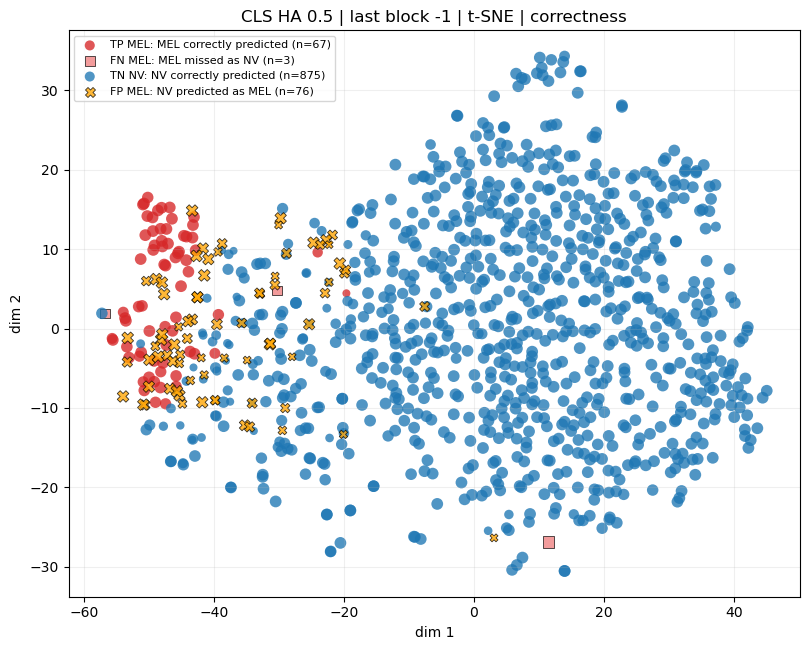

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/cls_ha05/tsne_correctness_last_block.png


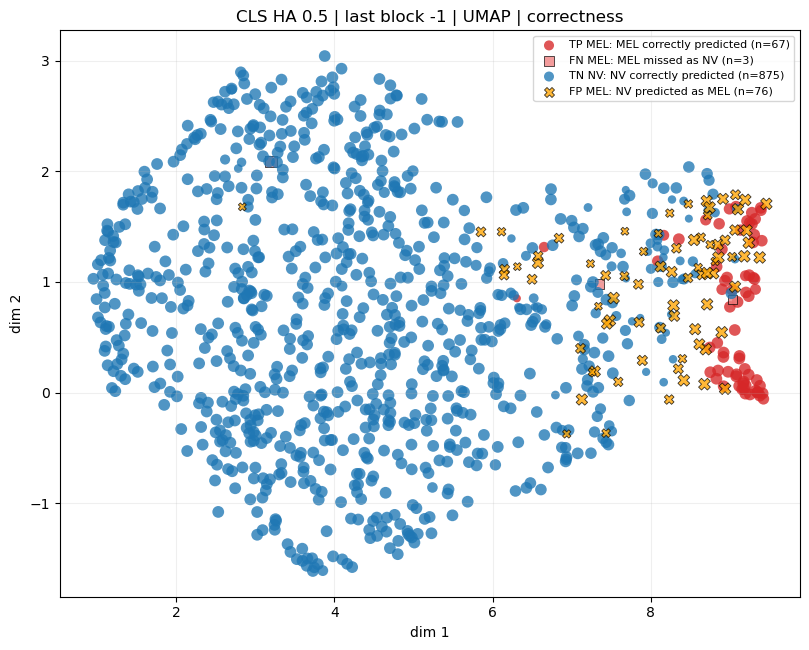

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/cls_ha05/umap_correctness_last_block.png


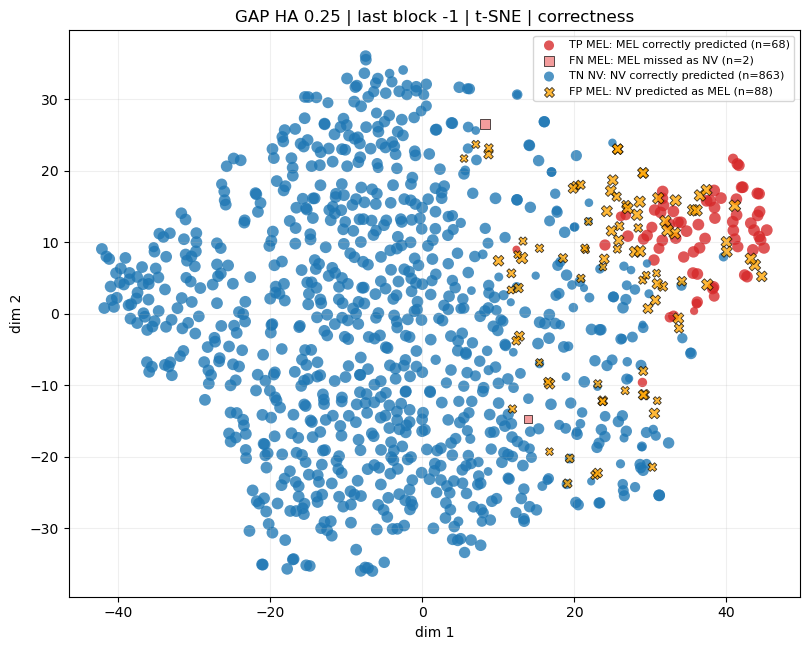

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/gap_ha025/tsne_correctness_last_block.png


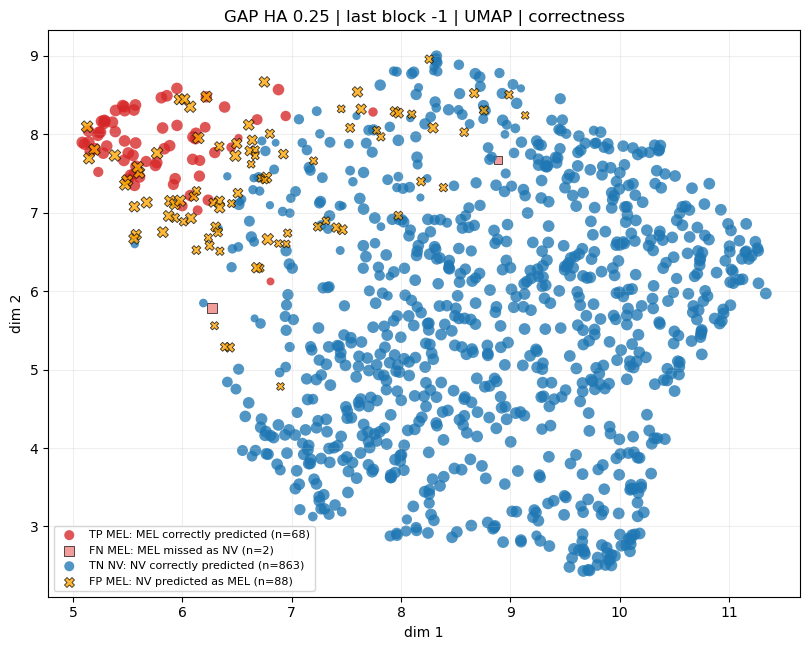

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/gap_ha025/umap_correctness_last_block.png


In [8]:

# Plot design:
# Same true class family has related color. Marker shape shows correct vs error.
STYLE = {
    "TP MEL": {"color": "tab:red", "marker": "o", "label": "TP MEL: MEL correctly predicted"},
    "FN MEL": {"color": "lightcoral", "marker": "s", "label": "FN MEL: MEL missed as NV"},
    "TN NV": {"color": "tab:blue", "marker": "o", "label": "TN NV: NV correctly predicted"},
    "FP MEL": {"color": "orange", "marker": "X", "label": "FP MEL: NV predicted as MEL"},
}
ORDER = ["TP MEL", "FN MEL", "TN NV", "FP MEL"]

def plot_correctness_embedding(meta, x_col, y_col, title, out_path):
    plt.figure(figsize=(8.2, 6.6))

    for cat in ORDER:
        sub = meta[meta["correctness"] == cat].copy()
        if len(sub) == 0:
            continue
        style = STYLE[cat]
        sizes = 32 + 80 * np.abs(sub["mel_probability"].values - 0.5)

        plt.scatter(
            sub[x_col],
            sub[y_col],
            s=sizes,
            c=style["color"],
            marker=style["marker"],
            alpha=0.78,
            edgecolors="black" if "FN" in cat or "FP" in cat else "none",
            linewidths=0.6,
            label=f"{style['label']} (n={len(sub)})",
        )

    plt.title(title)
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.legend(fontsize=8, frameon=True)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

for short_name, pack in FEATURE_PACKS.items():
    scenario = pack["scenario"]
    meta = pack["meta_test_emb"]
    out_dir = pack["out_dir"]

    if RUN_TSNE and {"tsne_1", "tsne_2"}.issubset(meta.columns):
        plot_correctness_embedding(
            meta,
            "tsne_1",
            "tsne_2",
            title=f"{scenario['name']} | last block {SELECTED_BLOCK} | t-SNE | correctness",
            out_path=out_dir / "tsne_correctness_last_block.png",
        )

    if RUN_UMAP and {"umap_1", "umap_2"}.issubset(meta.columns):
        plot_correctness_embedding(
            meta,
            "umap_1",
            "umap_2",
            title=f"{scenario['name']} | last block {SELECTED_BLOCK} | UMAP | correctness",
            out_path=out_dir / "umap_correctness_last_block.png",
        )


## 8. Side-by-side comparison plots

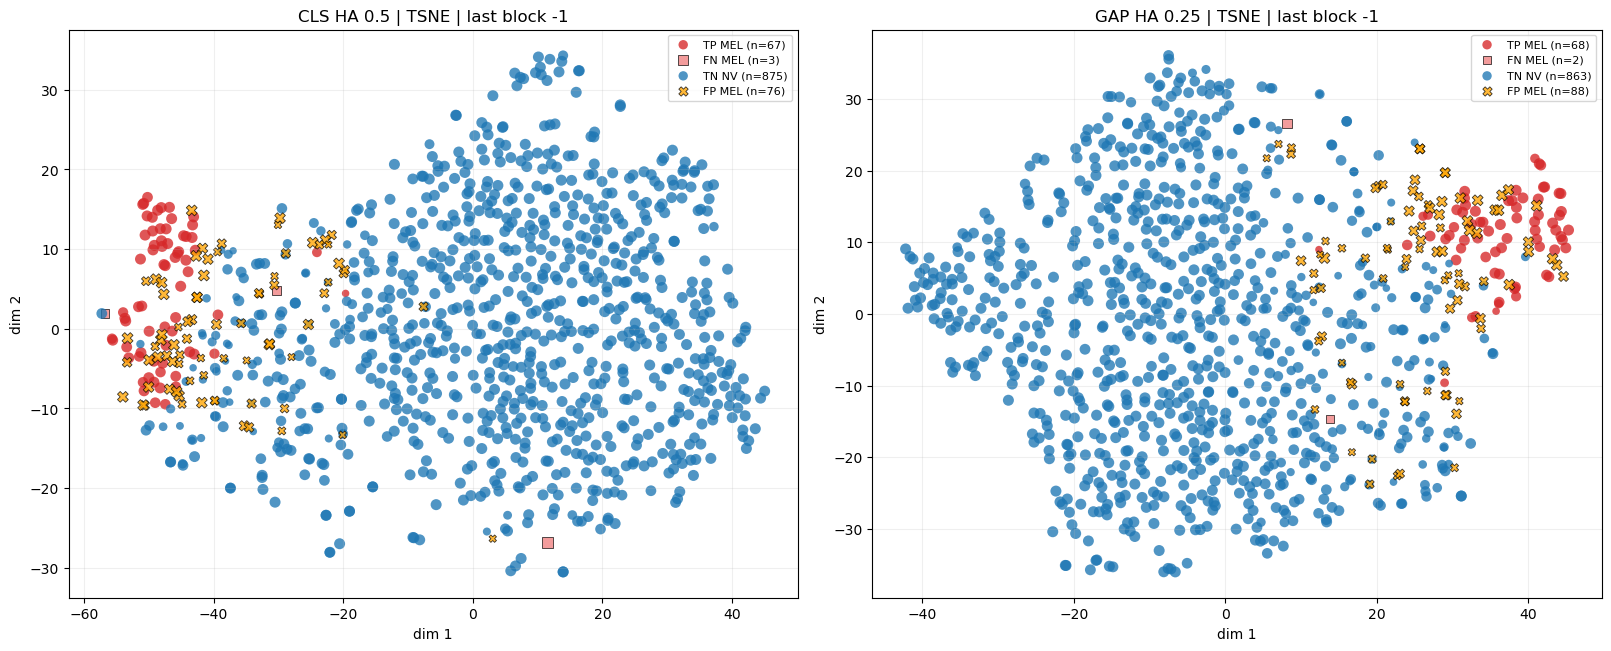

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/tsne_correctness_side_by_side_last_block.png


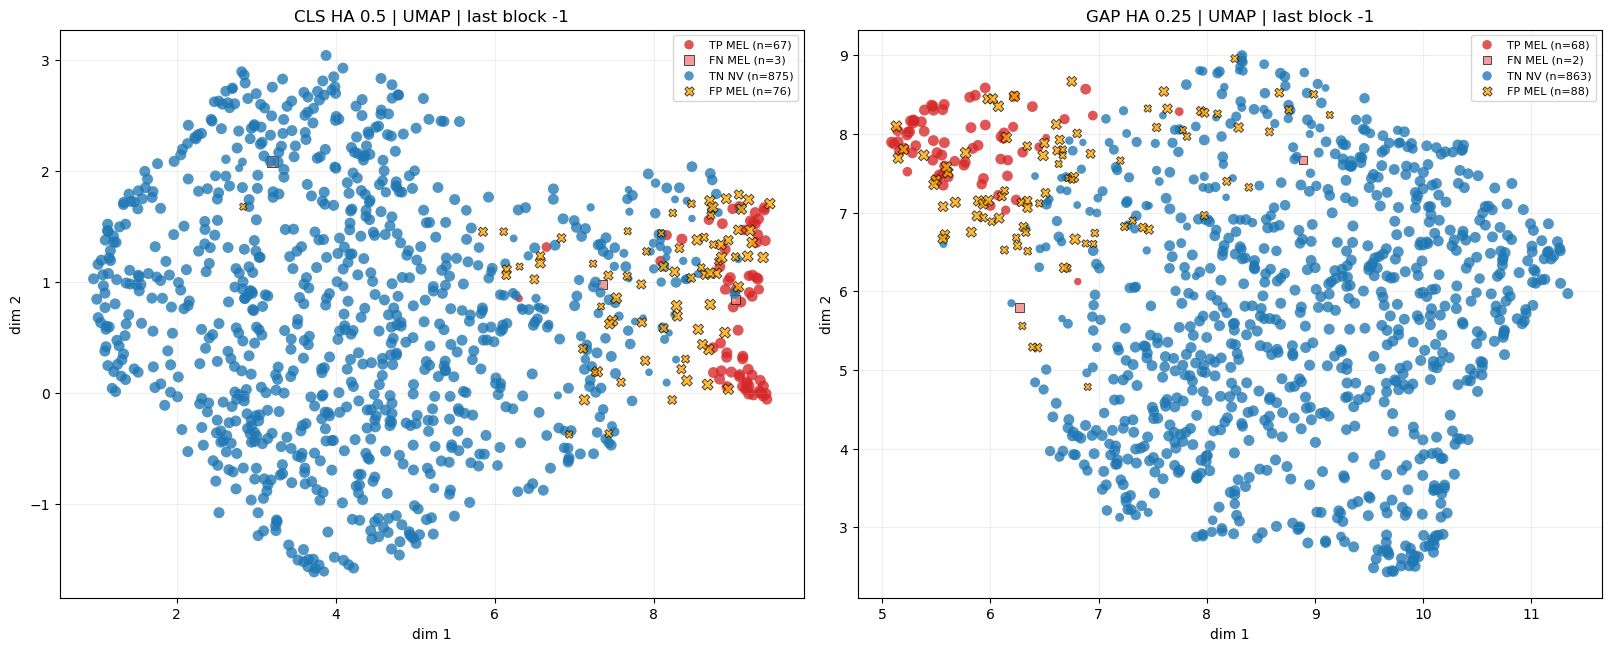

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/umap_correctness_side_by_side_last_block.png


In [9]:

def plot_side_by_side(method="umap"):
    if method == "umap":
        x_col, y_col = "umap_1", "umap_2"
    elif method == "tsne":
        x_col, y_col = "tsne_1", "tsne_2"
    else:
        raise ValueError(method)

    available = [
        (short_name, pack)
        for short_name, pack in FEATURE_PACKS.items()
        if x_col in pack["meta_test_emb"].columns and y_col in pack["meta_test_emb"].columns
    ]
    if len(available) == 0:
        print("No available embeddings for", method)
        return

    fig, axes = plt.subplots(1, len(available), figsize=(8 * len(available), 6.4), constrained_layout=True)
    if len(available) == 1:
        axes = [axes]

    for ax, (short_name, pack) in zip(axes, available):
        meta = pack["meta_test_emb"]
        scenario = pack["scenario"]

        for cat in ORDER:
            sub = meta[meta["correctness"] == cat].copy()
            if len(sub) == 0:
                continue
            style = STYLE[cat]
            sizes = 28 + 70 * np.abs(sub["mel_probability"].values - 0.5)
            ax.scatter(
                sub[x_col],
                sub[y_col],
                s=sizes,
                c=style["color"],
                marker=style["marker"],
                alpha=0.78,
                edgecolors="black" if "FN" in cat or "FP" in cat else "none",
                linewidths=0.6,
                label=f"{cat} (n={len(sub)})",
            )

        ax.set_title(f"{scenario['name']} | {method.upper()} | last block {SELECTED_BLOCK}")
        ax.set_xlabel("dim 1")
        ax.set_ylabel("dim 2")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)

    out_path = OUT_ROOT / f"{method}_correctness_side_by_side_last_block.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

plot_side_by_side("tsne")
plot_side_by_side("umap")


## 9. Export difficult cases

In [10]:

def add_original_columns(meta, original_test_df):
    keep_cols = [c for c in [ID_COL, IMAGE_COL, "mask_rel_path", "split", "age", "sex", "localization", "dataset"] if c in original_test_df.columns]
    if ID_COL not in keep_cols:
        return meta
    return meta.merge(original_test_df[keep_cols].drop_duplicates(ID_COL), on=ID_COL, how="left")

def export_difficult_cases(pack):
    scenario = pack["scenario"]
    out_dir = pack["out_dir"]
    meta = pack["meta_test_emb"].copy()
    meta = add_original_columns(meta, test_df)

    false_negative_mel = meta[meta["correctness"] == "FN MEL"].copy()
    false_positive_mel = meta[meta["correctness"] == "FP MEL"].copy()
    low_confidence = meta[meta["low_confidence"]].copy()
    errors = meta[~meta["correct"]].copy()

    false_negative_mel = false_negative_mel.sort_values("mel_probability", ascending=True)
    false_positive_mel = false_positive_mel.sort_values("mel_probability", ascending=False)
    low_confidence = low_confidence.sort_values("confidence_margin_to_0_5", ascending=True)
    errors = errors.sort_values(["correctness", "confidence_margin_to_0_5"])

    paths = {
        "false_negative_mel": out_dir / "difficult_false_negative_mel.csv",
        "false_positive_mel": out_dir / "difficult_false_positive_mel.csv",
        "low_confidence": out_dir / "difficult_low_confidence.csv",
        "all_errors": out_dir / "difficult_all_errors.csv",
    }

    false_negative_mel.to_csv(paths["false_negative_mel"], index=False)
    false_positive_mel.to_csv(paths["false_positive_mel"], index=False)
    low_confidence.to_csv(paths["low_confidence"], index=False)
    errors.to_csv(paths["all_errors"], index=False)

    print("\n" + "=" * 90)
    print("Difficult case export:", scenario["name"])
    print("=" * 90)
    print("FN MEL:", len(false_negative_mel), paths["false_negative_mel"])
    print("FP MEL:", len(false_positive_mel), paths["false_positive_mel"])
    print("Low confidence:", len(low_confidence), paths["low_confidence"])
    print("All errors:", len(errors), paths["all_errors"])

    display(errors.head(10))
    display(low_confidence.head(10))

for short_name, pack in FEATURE_PACKS.items():
    export_difficult_cases(pack)



Difficult case export: CLS HA 0.5
FN MEL: 3 /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/cls_ha05/difficult_false_negative_mel.csv
FP MEL: 76 /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/cls_ha05/difficult_false_positive_mel.csv
Low confidence: 44 /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/cls_ha05/difficult_low_confidence.csv
All errors: 79 /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/cls_ha05/difficult_all_errors.csv


,image_id,gt_label,label,mel_probability,nv_probability,pred_label_idx,pred_label,correct,correctness,confidence_margin_to_0_5,...,tsne_2,umap_1,umap_2,image_rel_path,mask_rel_path,split,age,sex,localization,dataset
5,ISIC_0024886,MEL,0,0.321379,0.678621,1,NV,False,FN MEL,0.178621,...,1.889713,9.030037,0.839528,images/ISIC_0024886.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,55.0,female,face,vidir_modern
47,ISIC_0030552,MEL,0,0.314705,0.685295,1,NV,False,FN MEL,0.185295,...,4.781841,7.351245,0.979390,images/ISIC_0030552.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,75.0,male,back,vidir_modern
30,ISIC_0028173,MEL,0,0.040932,0.959068,1,NV,False,FN MEL,0.459068,...,-26.838951,3.200304,2.088930,images/ISIC_0028173.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,45.0,male,back,vienna_dias
476,ISIC_0028067,NV,1,0.503654,0.496346,0,MEL,False,FP MEL,0.003654,...,-3.555381,7.338652,0.780164,images/ISIC_0028067.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,60.0,female,abdomen,vidir_modern
662,ISIC_0029624,NV,1,0.504446,0.495554,0,MEL,False,FP MEL,0.004446,...,10.560292,6.313916,1.138773,images/ISIC_0029624.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,45.0,female,trunk,vidir_molemax
705,ISIC_0030001,NV,1,0.508294,0.491706,0,MEL,False,FP MEL,0.008294,...,-26.343864,2.836659,1.679066,images/ISIC_0030001.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,75.0,male,abdomen,vidir_molemax
967,ISIC_0032554,NV,1,0.515467,0.484533,0,MEL,False,FP MEL,0.015467,...,-3.981358,7.672961,1.458134,images/ISIC_0032554.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,85.0,male,unknown,vidir_modern
807,ISIC_0030900,NV,1,0.526681,0.473319,0,MEL,False,FP MEL,0.026681,...,13.031208,7.259800,0.185207,images/ISIC_0030900.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,75.0,female,back,vidir_modern
983,ISIC_0033072,NV,1,0.537390,0.462610,0,MEL,False,FP MEL,0.037390,...,6.591479,7.237830,1.165114,images/ISIC_0033072.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,40.0,female,unknown,vidir_modern
313,ISIC_0026698,NV,1,0.548975,0.451024,0,MEL,False,FP MEL,0.048975,...,-3.680978,8.096117,1.438499,images/ISIC_0026698.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,60.0,male,lower extremity,rosendahl


,image_id,gt_label,label,mel_probability,nv_probability,pred_label_idx,pred_label,correct,correctness,confidence_margin_to_0_5,...,tsne_2,umap_1,umap_2,image_rel_path,mask_rel_path,split,age,sex,localization,dataset
73,ISIC_0024361,NV,1,0.498945,0.501055,1,NV,True,TN NV,0.001055,...,9.782252,8.194016,0.540902,images/ISIC_0024361.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,35.0,male,chest,vienna_dias
476,ISIC_0028067,NV,1,0.503654,0.496346,0,MEL,False,FP MEL,0.003654,...,-3.555381,7.338652,0.780164,images/ISIC_0028067.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,60.0,female,abdomen,vidir_modern
662,ISIC_0029624,NV,1,0.504446,0.495554,0,MEL,False,FP MEL,0.004446,...,10.560292,6.313916,1.138773,images/ISIC_0029624.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,45.0,female,trunk,vidir_molemax
705,ISIC_0030001,NV,1,0.508294,0.491706,0,MEL,False,FP MEL,0.008294,...,-26.343864,2.836659,1.679066,images/ISIC_0030001.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,75.0,male,abdomen,vidir_molemax
432,ISIC_0027688,NV,1,0.490361,0.509639,1,NV,True,TN NV,0.009639,...,-9.361060,7.867640,0.675710,images/ISIC_0027688.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,80.0,female,lower extremity,rosendahl
554,ISIC_0028724,NV,1,0.486957,0.513043,1,NV,True,TN NV,0.013043,...,6.963688,6.532840,0.776199,images/ISIC_0028724.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,45.0,female,trunk,vidir_molemax
35,ISIC_0029013,MEL,0,0.513999,0.486001,0,MEL,True,TP MEL,0.013999,...,4.435988,6.307714,0.851679,images/ISIC_0029013.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,45.0,female,abdomen,vidir_molemax
967,ISIC_0032554,NV,1,0.515467,0.484533,0,MEL,False,FP MEL,0.015467,...,-3.981358,7.672961,1.458134,images/ISIC_0032554.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,85.0,male,unknown,vidir_modern
188,ISIC_0025443,NV,1,0.482429,0.517570,1,NV,True,TN NV,0.017571,...,-4.898617,8.481645,1.572425,images/ISIC_0025443.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,75.0,male,back,rosendahl
984,ISIC_0033080,NV,1,0.479692,0.520308,1,NV,True,TN NV,0.020308,...,-13.991035,7.684278,1.832123,images/ISIC_0033080.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,60.0,male,trunk,vidir_modern



Difficult case export: GAP HA 0.25
FN MEL: 2 /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/gap_ha025/difficult_false_negative_mel.csv
FP MEL: 88 /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/gap_ha025/difficult_false_positive_mel.csv
Low confidence: 60 /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/gap_ha025/difficult_low_confidence.csv
All errors: 90 /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/gap_ha025/difficult_all_errors.csv


,image_id,gt_label,label,mel_probability,nv_probability,pred_label_idx,pred_label,correct,correctness,confidence_margin_to_0_5,...,tsne_2,umap_1,umap_2,image_rel_path,mask_rel_path,split,age,sex,localization,dataset
35,ISIC_0029013,MEL,0,0.466785,0.533215,1,NV,False,FN MEL,0.033215,...,-14.692278,8.886005,7.668405,images/ISIC_0029013.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,45.0,female,abdomen,vidir_molemax
30,ISIC_0028173,MEL,0,0.254813,0.745187,1,NV,False,FN MEL,0.245187,...,26.557819,6.270775,5.790432,images/ISIC_0028173.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,45.0,male,back,vienna_dias
981,ISIC_0032948,NV,1,0.500318,0.499682,0,MEL,False,FP MEL,0.000318,...,-6.804049,6.951885,6.600877,images/ISIC_0032948.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,45.0,female,upper extremity,vidir_modern
988,ISIC_0033224,NV,1,0.501472,0.498528,0,MEL,False,FP MEL,0.001472,...,8.961374,6.753123,7.415633,images/ISIC_0033224.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,30.0,female,back,vidir_modern
476,ISIC_0028067,NV,1,0.502614,0.497386,0,MEL,False,FP MEL,0.002614,...,-19.288019,9.135857,8.239657,images/ISIC_0028067.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,60.0,female,abdomen,vidir_modern
152,ISIC_0025014,NV,1,0.504581,0.495419,0,MEL,False,FP MEL,0.004581,...,21.733595,6.898409,4.783959,images/ISIC_0025014.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,35.0,male,trunk,vidir_molemax
784,ISIC_0030704,NV,1,0.504792,0.495208,0,MEL,False,FP MEL,0.004792,...,6.542393,6.718122,7.437936,images/ISIC_0030704.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,80.0,male,back,rosendahl
738,ISIC_0030308,NV,1,0.509978,0.490022,0,MEL,False,FP MEL,0.009978,...,8.281696,6.879321,6.606891,images/ISIC_0030308.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,45.0,female,trunk,vidir_molemax
282,ISIC_0026404,NV,1,0.519998,0.480002,0,MEL,False,FP MEL,0.019998,...,5.678053,6.630055,7.617692,images/ISIC_0026404.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,60.0,male,back,rosendahl
463,ISIC_0027978,NV,1,0.520026,0.479974,0,MEL,False,FP MEL,0.020026,...,-12.157200,7.453902,8.322441,images/ISIC_0027978.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,60.0,male,back,rosendahl


,image_id,gt_label,label,mel_probability,nv_probability,pred_label_idx,pred_label,correct,correctness,confidence_margin_to_0_5,...,tsne_2,umap_1,umap_2,image_rel_path,mask_rel_path,split,age,sex,localization,dataset
981,ISIC_0032948,NV,1,0.500318,0.499682,0,MEL,False,FP MEL,0.000318,...,-6.804049,6.951885,6.600877,images/ISIC_0032948.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,45.0,female,upper extremity,vidir_modern
988,ISIC_0033224,NV,1,0.501472,0.498528,0,MEL,False,FP MEL,0.001472,...,8.961374,6.753123,7.415633,images/ISIC_0033224.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,30.0,female,back,vidir_modern
78,ISIC_0024416,NV,1,0.498385,0.501615,1,NV,True,TN NV,0.001615,...,-1.502210,6.853840,7.890853,images/ISIC_0024416.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,65.0,female,back,rosendahl
476,ISIC_0028067,NV,1,0.502614,0.497386,0,MEL,False,FP MEL,0.002614,...,-19.288019,9.135857,8.239657,images/ISIC_0028067.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,60.0,female,abdomen,vidir_modern
152,ISIC_0025014,NV,1,0.504581,0.495419,0,MEL,False,FP MEL,0.004581,...,21.733595,6.898409,4.783959,images/ISIC_0025014.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,35.0,male,trunk,vidir_molemax
784,ISIC_0030704,NV,1,0.504792,0.495208,0,MEL,False,FP MEL,0.004792,...,6.542393,6.718122,7.437936,images/ISIC_0030704.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,80.0,male,back,rosendahl
46,ISIC_0030366,MEL,0,0.508613,0.491387,0,MEL,True,TP MEL,0.008613,...,8.989590,6.806884,6.122956,images/ISIC_0030366.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,60.0,female,back,vidir_molemax
738,ISIC_0030308,NV,1,0.509978,0.490022,0,MEL,False,FP MEL,0.009978,...,8.281696,6.879321,6.606891,images/ISIC_0030308.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,45.0,female,trunk,vidir_molemax
282,ISIC_0026404,NV,1,0.519998,0.480002,0,MEL,False,FP MEL,0.019998,...,5.678053,6.630055,7.617692,images/ISIC_0026404.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,60.0,male,back,rosendahl
463,ISIC_0027978,NV,1,0.520026,0.479974,0,MEL,False,FP MEL,0.020026,...,-12.157200,7.453902,8.322441,images/ISIC_0027978.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,test,60.0,male,back,rosendahl


## 10. Nearest neighbors for errors and low-confidence cases

In [11]:

def nearest_neighbor_table(pack, query_case="errors", top_k=5):
    scenario = pack["scenario"]
    out_dir = pack["out_dir"]

    X_test = pack["X_test"]
    meta = pack["meta_test_emb"].copy().reset_index(drop=True)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_test)

    nn = NearestNeighbors(n_neighbors=top_k + 1, metric="euclidean")
    nn.fit(Xs)

    if query_case == "errors":
        query_idx = meta.index[~meta["correct"]].tolist()
    elif query_case == "false_negative_mel":
        query_idx = meta.index[meta["correctness"].eq("FN MEL")].tolist()
    elif query_case == "false_positive_mel":
        query_idx = meta.index[meta["correctness"].eq("FP MEL")].tolist()
    elif query_case == "low_confidence":
        query_idx = meta.index[meta["low_confidence"]].tolist()
    else:
        raise ValueError(query_case)

    rows = []
    for qi in query_idx:
        distances, indices = nn.kneighbors(Xs[qi:qi+1], n_neighbors=top_k + 1)
        indices = indices[0].tolist()
        distances = distances[0].tolist()

        # Remove self.
        neigh = [(j, d) for j, d in zip(indices, distances) if j != qi][:top_k]

        q = meta.iloc[qi]
        neighbor_ids = [meta.iloc[j]["image_id"] for j, _ in neigh]
        neighbor_gt = [meta.iloc[j]["gt_label"] for j, _ in neigh]
        neighbor_pred = [meta.iloc[j]["pred_label"] for j, _ in neigh]
        neighbor_corr = [meta.iloc[j]["correctness"] for j, _ in neigh]
        neighbor_dist = [float(d) for _, d in neigh]
        same_label_fraction = float(np.mean([g == q["gt_label"] for g in neighbor_gt])) if neighbor_gt else np.nan

        rows.append({
            "model": scenario["name"],
            "short_name": scenario["short_name"],
            "query_case": query_case,
            "query_image_id": q["image_id"],
            "query_gt": q["gt_label"],
            "query_pred": q["pred_label"],
            "query_correctness": q["correctness"],
            "query_mel_probability": q["mel_probability"],
            "neighbor_image_ids": ", ".join(map(str, neighbor_ids)),
            "neighbor_gt_labels": ", ".join(map(str, neighbor_gt)),
            "neighbor_pred_labels": ", ".join(map(str, neighbor_pred)),
            "neighbor_correctness": ", ".join(map(str, neighbor_corr)),
            "neighbor_distances": ", ".join([f"{d:.3f}" for d in neighbor_dist]),
            "same_label_fraction": same_label_fraction,
        })

    out = pd.DataFrame(rows)
    out_path = out_dir / f"nearest_neighbors_{query_case}.csv"
    out.to_csv(out_path, index=False)
    print("Saved:", out_path, "shape:", out.shape)
    return out

NN_TABLES = []
for short_name, pack in FEATURE_PACKS.items():
    for case in ["errors", "false_negative_mel", "false_positive_mel", "low_confidence"]:
        tbl = nearest_neighbor_table(pack, query_case=case, top_k=5)
        NN_TABLES.append(tbl)

combined_nn = pd.concat(NN_TABLES, axis=0).reset_index(drop=True) if NN_TABLES else pd.DataFrame()
combined_nn_path = OUT_ROOT / "nearest_neighbors_combined.csv"
combined_nn.to_csv(combined_nn_path, index=False)
display(combined_nn.head(20))
print("Saved combined nearest-neighbor table:", combined_nn_path)


Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/cls_ha05/nearest_neighbors_errors.csv shape: (79, 14)
Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/cls_ha05/nearest_neighbors_false_negative_mel.csv shape: (3, 14)
Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/cls_ha05/nearest_neighbors_false_positive_mel.csv shape: (76, 14)
Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/cls_ha05/nearest_neighbors_low_confidence.csv shape: (44, 14)
Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/gap_ha025/nearest_neighbors_errors.csv shape: (90, 14)
Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/ga

,model,short_name,query_case,query_image_id,query_gt,query_pred,query_correctness,query_mel_probability,neighbor_image_ids,neighbor_gt_labels,neighbor_pred_labels,neighbor_correctness,neighbor_distances,same_label_fraction
0,CLS HA 0.5,cls_ha05,errors,ISIC_0024886,MEL,NV,FN MEL,0.321379,"ISIC_0024863, ISIC_0032295, ISIC_0028882, ISIC...","NV, NV, NV, MEL, MEL","NV, NV, MEL, MEL, MEL","TN NV, TN NV, FP MEL, TP MEL, TP MEL","29.433, 29.486, 29.677, 29.683, 30.084",0.4
1,CLS HA 0.5,cls_ha05,errors,ISIC_0028173,MEL,NV,FN MEL,0.040932,"ISIC_0029566, ISIC_0025120, ISIC_0030152, ISIC...","NV, NV, NV, NV, NV","NV, NV, NV, NV, NV","TN NV, TN NV, TN NV, TN NV, TN NV","28.978, 29.193, 29.783, 30.581, 30.622",0.0
2,CLS HA 0.5,cls_ha05,errors,ISIC_0030552,MEL,NV,FN MEL,0.314705,"ISIC_0033101, ISIC_0030479, ISIC_0033697, ISIC...","NV, NV, NV, NV, NV","MEL, NV, NV, NV, NV","FP MEL, TN NV, TN NV, TN NV, TN NV","24.960, 26.610, 26.801, 27.294, 27.704",0.0
3,CLS HA 0.5,cls_ha05,errors,ISIC_0024344,NV,MEL,FP MEL,0.994135,"ISIC_0025836, ISIC_0026150, ISIC_0033916, ISIC...","NV, MEL, NV, MEL, MEL","MEL, MEL, MEL, MEL, MEL","FP MEL, TP MEL, FP MEL, TP MEL, TP MEL","26.372, 29.225, 29.710, 31.174, 31.472",0.4
4,CLS HA 0.5,cls_ha05,errors,ISIC_0024416,NV,MEL,FP MEL,0.842351,"ISIC_0029089, ISIC_0026491, ISIC_0024716, ISIC...","MEL, NV, NV, NV, MEL","MEL, MEL, MEL, MEL, MEL","TP MEL, FP MEL, FP MEL, FP MEL, TP MEL","26.364, 26.555, 26.856, 27.265, 27.544",0.6
5,CLS HA 0.5,cls_ha05,errors,ISIC_0024620,NV,MEL,FP MEL,0.575805,"ISIC_0032340, ISIC_0031177, ISIC_0033735, ISIC...","NV, MEL, NV, NV, NV","NV, MEL, NV, NV, NV","TN NV, TP MEL, TN NV, TN NV, TN NV","20.583, 23.303, 26.291, 26.419, 27.121",0.8
6,CLS HA 0.5,cls_ha05,errors,ISIC_0024704,NV,MEL,FP MEL,0.784900,"ISIC_0027688, ISIC_0032340, ISIC_0031802, ISIC...","NV, NV, NV, NV, NV","NV, NV, NV, MEL, NV","TN NV, TN NV, TN NV, FP MEL, TN NV","20.220, 28.404, 29.358, 29.649, 30.423",1.0
7,CLS HA 0.5,cls_ha05,errors,ISIC_0024716,NV,MEL,FP MEL,0.908564,"ISIC_0026491, ISIC_0030625, ISIC_0030733, ISIC...","NV, NV, NV, NV, MEL","MEL, MEL, MEL, MEL, MEL","FP MEL, FP MEL, FP MEL, FP MEL, TP MEL","24.141, 24.809, 25.651, 26.260, 26.702",0.8
8,CLS HA 0.5,cls_ha05,errors,ISIC_0024944,NV,MEL,FP MEL,0.990962,"ISIC_0029132, ISIC_0028999, ISIC_0028828, ISIC...","NV, NV, NV, NV, MEL","MEL, MEL, MEL, MEL, MEL","FP MEL, FP MEL, FP MEL, FP MEL, TP MEL","23.493, 24.980, 25.215, 25.542, 25.588",0.8
9,CLS HA 0.5,cls_ha05,errors,ISIC_0025214,NV,MEL,FP MEL,0.971545,"ISIC_0029089, ISIC_0026491, ISIC_0025414, ISIC...","MEL, NV, MEL, MEL, MEL","MEL, MEL, MEL, MEL, MEL","TP MEL, FP MEL, TP MEL, TP MEL, TP MEL","21.270, 22.597, 22.781, 24.595, 24.920",0.2


Saved combined nearest-neighbor table: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/mel_nv/feature_space_difficult_cases_last_block/nearest_neighbors_combined.csv


## 11. Final summary print

In [12]:

print("=" * 100)
print("04b FEATURE-SPACE DIFFICULT CASE SUMMARY")
print("=" * 100)

display(metrics_df)

for short_name, pack in FEATURE_PACKS.items():
    scenario = pack["scenario"]
    meta = pack["meta_test_emb"]
    n = len(meta)
    counts = meta["correctness"].value_counts().reindex(ORDER, fill_value=0)

    print("\n" + scenario["name"])
    print("-" * 80)
    print(f"Test samples: {n}")
    for cat in ORDER:
        print(f"{cat:7s}: {counts[cat]:4d} ({counts[cat] / max(n,1):.1%})")
    print(f"Low-confidence cases abs(MEL_prob - 0.5) <= {LOW_CONF_MARGIN}: {int(meta['low_confidence'].sum())}")

print("\nInterpretation:")
print("- Use the t-SNE/UMAP plots to inspect where errors and low-confidence cases sit.")
print("- Use FN MEL as the highest-priority dermatologist review group because these are missed melanomas.")
print("- Use FP MEL as false-alarm cases where NV is predicted as MEL.")
print("- Do not use this notebook alone to choose the CAM block. It supports representation analysis and difficult-case selection.")
print("=" * 100)


04b FEATURE-SPACE DIFFICULT CASE SUMMARY


,model,short_name,pooling,feature_mode,block,resolved_index,knn_accuracy,knn_balanced_accuracy,linear_probe_accuracy,linear_probe_balanced_accuracy,silhouette,centroid_distance
0,CLS HA 0.5,cls_ha05,CLS token pooling,matching_pooling,-1,11,0.966699,0.876251,0.961802,0.886856,0.175008,24.628908
1,GAP HA 0.25,gap_ha025,GAP / mean pooling,matching_pooling,-1,11,0.963761,0.841588,0.957884,0.864902,0.207656,26.723803



CLS HA 0.5
--------------------------------------------------------------------------------
Test samples: 1021
TP MEL :   67 (6.6%)
FN MEL :    3 (0.3%)
TN NV  :  875 (85.7%)
FP MEL :   76 (7.4%)
Low-confidence cases abs(MEL_prob - 0.5) <= 0.15: 44

GAP HA 0.25
--------------------------------------------------------------------------------
Test samples: 1021
TP MEL :   68 (6.7%)
FN MEL :    2 (0.2%)
TN NV  :  863 (84.5%)
FP MEL :   88 (8.6%)
Low-confidence cases abs(MEL_prob - 0.5) <= 0.15: 60

Interpretation:
- Use the t-SNE/UMAP plots to inspect where errors and low-confidence cases sit.
- Use FN MEL as the highest-priority dermatologist review group because these are missed melanomas.
- Use FP MEL as false-alarm cases where NV is predicted as MEL.
- Do not use this notebook alone to choose the CAM block. It supports representation analysis and difficult-case selection.
